# Model comparison: three-model table

Compares only three models across participants:

1. **Causal-inference averaging** (`lognorm_sharedPrior`)
2. **Forced fusion** (`fusionOnlyLogNorm_sharedPrior`)
3. **Probabilistic cue switching** (`switchingFree_sharedPrior`)

Two sources are loaded: `unimodal_sigma` (sensory-noise parameters fixed from unimodal fits) and `free_sigma` (sensory-noise parameters fit freely).

In [11]:
import os
import json
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import digamma, gammaln
from scipy.stats import dirichlet as dirichlet_dist

## 1. Config: only keep the three target models

In [12]:
# Map raw model tag -> display name. Only the three target models.
TARGET_MODELS = {
    'lognorm_sharedPrior': 'Causal-inference averaging',
    'fusionOnlyLogNorm_sharedPrior': 'Forced fusion',
    'switchingFree_sharedPrior': 'Probabilistic cue switching',
}

# Order used in plots / tables
MODEL_ORDER = [
    'Forced fusion',
    'Causal-inference averaging',
    'Probabilistic cue switching',
]

# Baseline for delta criteria in the comparison table.
BASE_MODEL = 'Forced fusion'


FIT_SOURCE_CONFIGS = {
    'free_sigma': {
        'glob_pattern': 'model_fits/**/*.json',
        'exclude_filename_substrings': ('all', 'lnd1', 'ln1', 'loglinear'),
        'exclude_tags': ('LapseFree',),
    },
    'unimodal_sigma': {
        'glob_pattern': 'unimodalSigma_modelFits/**/*.json',
        'exclude_filename_substrings': ('all', 'lnd1', 'ln1', 'loglinear'),
        'exclude_tags': (),
    },
}

## 2. Load fits and keep only target models

In [13]:
def load_target_model_results(source):
    """Load JSON fits and keep only rows for the three target models."""
    config = FIT_SOURCE_CONFIGS[source]
    json_files = sorted(glob.glob(config['glob_pattern'], recursive=True))

    results = []
    for file_path in json_files:
        filename = os.path.basename(file_path)
        filename_lower = filename.lower()

        if any(s in filename_lower for s in config['exclude_filename_substrings']):
            continue
        if config['exclude_tags'] and any(tag in filename for tag in config['exclude_tags']):
            continue

        parts = filename.replace('.json', '').split('_')
        # convention: <pid>_<modelBase>_<lapseTag>_<priorTag>_fit.json
        raw_model_tag = f"{parts[1]}_{parts[3]}"
        if raw_model_tag not in TARGET_MODELS:
            continue

        with open(file_path, 'r') as f:
            result = json.load(f)

        result['participantID'] = result.get('participantID', parts[0]).lower()
        result['modelType'] = TARGET_MODELS[raw_model_tag]
        result['fit_source'] = source
        result['fit_file'] = file_path
        results.append(result)

    df = pd.DataFrame(results)
    if df.empty:
        return df

    df['participantID'] = df['participantID'].astype(str).str.lower()
    df['nParameters'] = df['fittedParams'].apply(len)
    df['AIC_recalculated'] = 2 * df['nParameters'] - 2 * df['logLikelihood']
    df['AIC'] = df['AIC_recalculated']
    return df


df_free = load_target_model_results('free_sigma')
df_unimodal = load_target_model_results('unimodal_sigma')

print(f"free_sigma:     {len(df_free)} rows, participants={sorted(df_free['participantID'].unique())}")
print(f"unimodal_sigma: {len(df_unimodal)} rows, participants={sorted(df_unimodal['participantID'].unique())}")
print(f"Models present: {sorted(df_free['modelType'].unique())}")

free_sigma:     33 rows, participants=['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']
unimodal_sigma: 33 rows, participants=['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']
Models present: ['Causal-inference averaging', 'Forced fusion', 'Probabilistic cue switching']


## 3. Best-fit summary per participant

In [14]:
def best_model_summary(df_results, criterion='AIC'):
    rows = []
    for pid in sorted(df_results['participantID'].unique()):
        sub = df_results[df_results['participantID'] == pid]
        best = sub.loc[sub[criterion].idxmin()]
        rows.append({
            'participantID': pid,
            'best_model': best['modelType'],
            'AIC': best['AIC'],
            'BIC': best['BIC'],
            'logLikelihood': best['logLikelihood'],
        })
    return pd.DataFrame(rows)


best_free = best_model_summary(df_free)
best_uni = best_model_summary(df_unimodal)

print('Best model per participant (free sigma):')
print(best_free.round(2).to_string(index=False))
print('\nBest model per participant (unimodal sigma):')
print(best_uni.round(2).to_string(index=False))

print('\nBest-model counts (free_sigma):')
print(best_free['best_model'].value_counts())
print('\nBest-model counts (unimodal_sigma):')
print(best_uni['best_model'].value_counts())

Best model per participant (free sigma):
participantID                  best_model     AIC     BIC  logLikelihood
           as               Forced fusion 2246.44 2262.63       -1119.22
           dt               Forced fusion 2548.12 2564.57       -1270.06
           hh  Causal-inference averaging 1193.90 1213.99        -591.95
           ip Probabilistic cue switching 2401.43 2426.64       -1194.72
          ln2  Causal-inference averaging 2167.37 2188.34       -1078.69
           mh  Causal-inference averaging 2438.93 2460.13       -1214.46
           ml Probabilistic cue switching 2508.71 2535.08       -1248.35
           mt Probabilistic cue switching 2207.74 2231.02       -1097.87
           oy Probabilistic cue switching 2319.58 2346.66       -1153.79
           qs               Forced fusion 2498.54 2515.30       -1245.27
           sx Probabilistic cue switching 2140.07 2165.90       -1064.03

Best model per participant (unimodal sigma):
participantID                  best_m

## 4. Sum ΔAIC with participant bootstrap

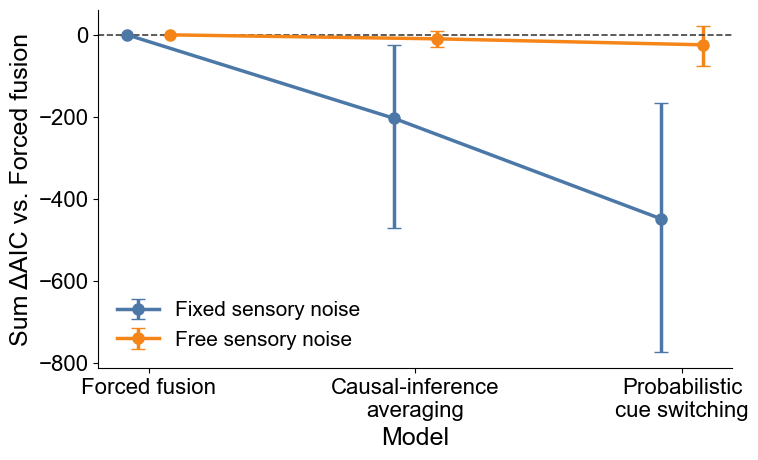

                  modelType  sum_deltaAIC  ci_low  ci_high          fit_source
              Forced fusion          0.00    0.00     0.00 Fixed sensory noise
 Causal-inference averaging       -203.50 -471.95   -25.95 Fixed sensory noise
Probabilistic cue switching       -448.27 -773.48  -166.33 Fixed sensory noise
              Forced fusion          0.00    0.00     0.00  Free sensory noise
 Causal-inference averaging         -9.67  -30.44     9.97  Free sensory noise
Probabilistic cue switching        -24.31  -75.71    20.87  Free sensory noise


In [15]:
PANEL_SPECS = [
    {'label': 'Fixed sensory noise', 'df': df_unimodal},
    {'label': 'Free sensory noise', 'df': df_free},
]

FONT_SIZE = 18
BOOTSTRAP_ITERATIONS = 5000
BOOTSTRAP_CI = (2.5, 97.5)


def wrap_label(text, max_chars=15):
    words = text.split()
    if not words:
        return text
    lines = [words[0]]
    for word in words[1:]:
        candidate = f"{lines[-1]} {word}"
        if len(candidate) <= max_chars:
            lines[-1] = candidate
        else:
            lines.append(word)
    return "\n".join(lines)


def delta_aic_matrix(df_results, base_model=BASE_MODEL):
    df = df_results.copy()
    base = df.loc[df['modelType'] == base_model, ['participantID', 'AIC']].rename(
        columns={'AIC': 'base_AIC'}
    )
    missing_base = sorted(set(df['participantID']) - set(base['participantID']))
    if missing_base:
        raise ValueError(f"Missing {base_model!r} rows for participants: {missing_base}")
    df = df.merge(base, on='participantID', how='left', validate='many_to_one')
    df['deltaAIC'] = df['AIC'] - df['base_AIC']
    matrix = df.pivot(index='participantID', columns='modelType', values='deltaAIC')
    participant_order = sorted(matrix.index)
    model_order = [m for m in MODEL_ORDER if m in matrix.columns]
    return matrix.reindex(index=participant_order, columns=model_order)


def bootstrap_sum_delta_aic(delta_matrix, n_boot=BOOTSTRAP_ITERATIONS, ci=BOOTSTRAP_CI, seed=1):
    values = delta_matrix.to_numpy(dtype=float)
    rng = np.random.default_rng(seed)
    n_participants = values.shape[0]
    sample_idx = rng.integers(0, n_participants, size=(n_boot, n_participants))
    boot_sums = values[sample_idx].sum(axis=1)
    observed = values.sum(axis=0)
    ci_low, ci_high = np.percentile(boot_sums, ci, axis=0)
    return pd.DataFrame({
        'modelType': delta_matrix.columns,
        'sum_deltaAIC': observed,
        'ci_low': ci_low,
        'ci_high': ci_high,
    })


def plot_sum_delta_aic_with_bootstrap(base_model=BASE_MODEL, save_path='sumDeltaAIC_threeModels.pdf'):
    summaries = []
    for i, spec in enumerate(PANEL_SPECS):
        delta_matrix = delta_aic_matrix(spec['df'], base_model=base_model)
        summary = bootstrap_sum_delta_aic(delta_matrix, seed=1 + i)
        summary['fit_source'] = spec['label']
        summaries.append(summary)

    summary_df = pd.concat(summaries, ignore_index=True)
    x = np.arange(len(MODEL_ORDER))
    offsets = np.linspace(-0.08, 0.08, len(PANEL_SPECS))
    colors = ['#4C78A8', '#F58518']

    fig, ax = plt.subplots(figsize=(8, 5))
    for offset, color, spec in zip(offsets, colors, PANEL_SPECS):
        sub = summary_df[summary_df['fit_source'] == spec['label']].set_index('modelType').reindex(MODEL_ORDER)
        y = sub['sum_deltaAIC'].to_numpy(dtype=float)
        yerr = np.vstack([
            y - sub['ci_low'].to_numpy(dtype=float),
            sub['ci_high'].to_numpy(dtype=float) - y,
        ])
        ax.errorbar(
            x + offset, y, yerr=yerr, marker='o', linestyle='-', linewidth=2.5,
            markersize=8, capsize=5, color=color, label=spec['label'],
        )

    ax.axhline(0, color='0.25', linewidth=1.2, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([wrap_label(m) for m in MODEL_ORDER], fontsize=FONT_SIZE - 2)
    ax.set_ylabel(f'Sum ΔAIC vs. {base_model}', fontsize=FONT_SIZE)
    ax.set_xlabel('Model', fontsize=FONT_SIZE)
    ax.tick_params(axis='y', labelsize=FONT_SIZE - 2)
    ax.legend(frameon=False, fontsize=FONT_SIZE - 3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()

    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()

    return summary_df


sum_delta_aic_bootstrap = plot_sum_delta_aic_with_bootstrap()
print(sum_delta_aic_bootstrap.round(2).to_string(index=False))

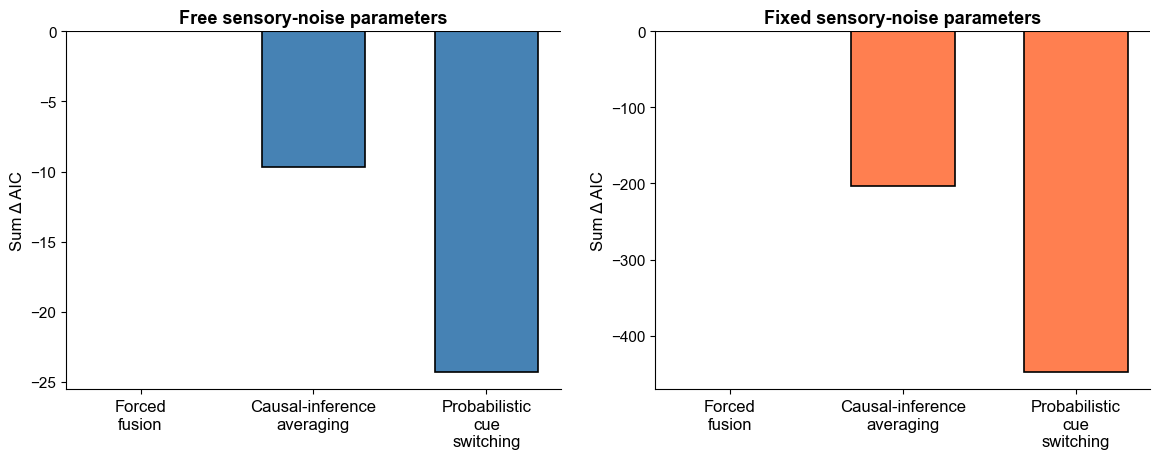

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Free sigma
axes[0].bar(range(len(free_sum_delta_aic)), free_sum_delta_aic['sum_deltaAIC'].values, 
            width=0.6, color='steelblue', edgecolor='black', linewidth=1.2)
axes[0].set_xticks(range(len(free_sum_delta_aic)))
axes[0].set_xticklabels([m.replace(' ', '\n') for m in free_sum_delta_aic.index], fontsize=12)
axes[0].set_ylabel('Sum Δ AIC', fontsize=12)
axes[0].set_title('Free sensory-noise parameters', fontsize=13, fontweight='bold')
axes[0].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='y', labelsize=11)

# Unimodal sigma
axes[1].bar(range(len(uni_sum_delta_aic)), uni_sum_delta_aic['sum_deltaAIC'].values, 
            width=0.6, color='coral', edgecolor='black', linewidth=1.2)
axes[1].set_xticks(range(len(uni_sum_delta_aic)))
axes[1].set_xticklabels([m.replace(' ', '\n') for m in uni_sum_delta_aic.index], fontsize=12)
axes[1].set_ylabel('Sum Δ AIC', fontsize=12)
axes[1].set_title('Fixed sensory-noise parameters', fontsize=13, fontweight='bold')
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.savefig('sumDeltaAIC_comparison.pdf', dpi=600, bbox_inches='tight')
plt.savefig('sumDeltaAIC_comparison.svg', format='svg', bbox_inches='tight')
plt.show()

## 5. Random-effects Bayesian model selection

Variational Bayes (Stephan et al., 2009) and protected exceedance probabilities (Rigoux et al., 2014), using −½ AIC as the log model evidence.

In [17]:
def build_log_evidence_matrix(df_results, models_ordered):
    participants = sorted(df_results['participantID'].unique())
    K = len(models_ordered)
    N = len(participants)
    L = np.full((N, K), -np.inf)
    for i, pid in enumerate(participants):
        for j, mod in enumerate(models_ordered):
            row = df_results[(df_results['participantID'] == pid) & (df_results['modelType'] == mod)]
            if len(row) == 1:
                L[i, j] = -0.5 * row['AIC'].values[0]
    return L, participants


def spm_BMS_vb(L, alpha0=None, max_iter=500, tol=1e-6):
    N, K = L.shape
    if alpha0 is None:
        alpha0 = np.ones(K)
    L = L - L.max(axis=1, keepdims=True)
    alpha = alpha0.copy()
    for _ in range(max_iter):
        psi_sum = digamma(alpha.sum())
        log_u = digamma(alpha) - psi_sum
        log_g = L + log_u[np.newaxis, :]
        log_g = log_g - log_g.max(axis=1, keepdims=True)
        g = np.exp(log_g)
        g = g / g.sum(axis=1, keepdims=True)
        alpha_new = alpha0 + g.sum(axis=0)
        if np.max(np.abs(alpha_new - alpha)) < tol:
            alpha = alpha_new
            break
        alpha = alpha_new
    r = alpha / alpha.sum()
    samples = dirichlet_dist.rvs(alpha, size=1_000_000)
    xp = (samples.argmax(axis=1)[:, None] == np.arange(K)[None, :]).mean(axis=0)
    return alpha, r, xp


def _free_energy(L, alpha, alpha0):
    psi_sum = digamma(alpha.sum())
    log_u = digamma(alpha) - psi_sum
    L_stable = L - L.max(axis=1, keepdims=True)
    log_g = L_stable + log_u[np.newaxis, :]
    log_g = log_g - log_g.max(axis=1, keepdims=True)
    g = np.exp(log_g); g = g / g.sum(axis=1, keepdims=True); g = np.clip(g, 1e-300, None)
    E_ll = np.sum(g * L)
    H_g = -np.sum(g * np.log(g))
    KL = (gammaln(alpha.sum()) - gammaln(alpha0.sum())
          + np.sum(gammaln(alpha0) - gammaln(alpha))
          + np.sum((alpha - alpha0) * (digamma(alpha) - psi_sum)))
    return E_ll + H_g - KL


def _free_energy_null(L, alpha0):
    K = L.shape[1]
    log_u = np.log(np.ones(K) / K)
    L_stable = L - L.max(axis=1, keepdims=True)
    log_g = L_stable + log_u[np.newaxis, :]
    log_g = log_g - log_g.max(axis=1, keepdims=True)
    g = np.exp(log_g); g = g / g.sum(axis=1, keepdims=True); g = np.clip(g, 1e-300, None)
    return np.sum(g * L) - np.sum(g * np.log(g))


def bayesian_omnibus_risk(L, alpha0=None):
    if alpha0 is None:
        alpha0 = np.ones(L.shape[1])
    alpha_fit, _, _ = spm_BMS_vb(L, alpha0=alpha0)
    F1 = _free_energy(L, alpha_fit, alpha0)
    F0 = _free_energy_null(L, alpha0)
    return 1.0 / (1.0 + np.exp(F1 - F0))


def run_bms(df_results, models_ordered, label=''):
    L, pids = build_log_evidence_matrix(df_results, models_ordered)
    alpha_post, r_freq, xp = spm_BMS_vb(L)
    bor = bayesian_omnibus_risk(L)
    pxp = xp * (1 - bor) + bor / len(models_ordered)
    print(f"\n{'=' * 64}\nRandom-effects BMS {label}\n{'=' * 64}")
    print(f"N = {len(pids)} participants, K = {len(models_ordered)} models\n")
    print(f"{'Model':<32s} {'E[r]':>8s} {'XP':>8s} {'PXP':>8s}")
    print('-' * 60)
    for j, mod in enumerate(models_ordered):
        print(f"{mod:<32s} {r_freq[j]:8.3f} {xp[j]:8.3f} {pxp[j]:8.3f}")
    print('-' * 60)
    print(f"BOR = {bor:.3f}")
    return {'alpha': alpha_post, 'r': r_freq, 'xp': xp, 'pxp': pxp, 'bor': bor,
            'models': models_ordered, 'participants': pids}


bms_free = run_bms(df_free, MODEL_ORDER, label='(free sigma)')
bms_uni = run_bms(df_unimodal, MODEL_ORDER, label='(unimodal sigma)')


Random-effects BMS (free sigma)
N = 11 participants, K = 3 models

Model                                E[r]       XP      PXP
------------------------------------------------------------
Forced fusion                       0.231    0.096    0.279
Causal-inference averaging          0.310    0.224    0.308
Probabilistic cue switching         0.459    0.680    0.413
------------------------------------------------------------
BOR = 0.770

Random-effects BMS (unimodal sigma)
N = 11 participants, K = 3 models

Model                                E[r]       XP      PXP
------------------------------------------------------------
Forced fusion                       0.076    0.002    0.290
Causal-inference averaging          0.279    0.067    0.298
Probabilistic cue switching         0.646    0.931    0.412
------------------------------------------------------------
BOR = 0.868


## 6. PXP plot (free-sigma source)

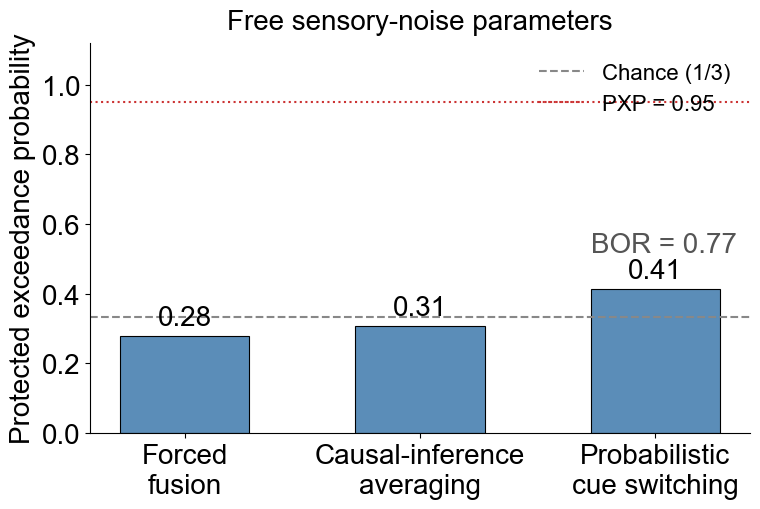

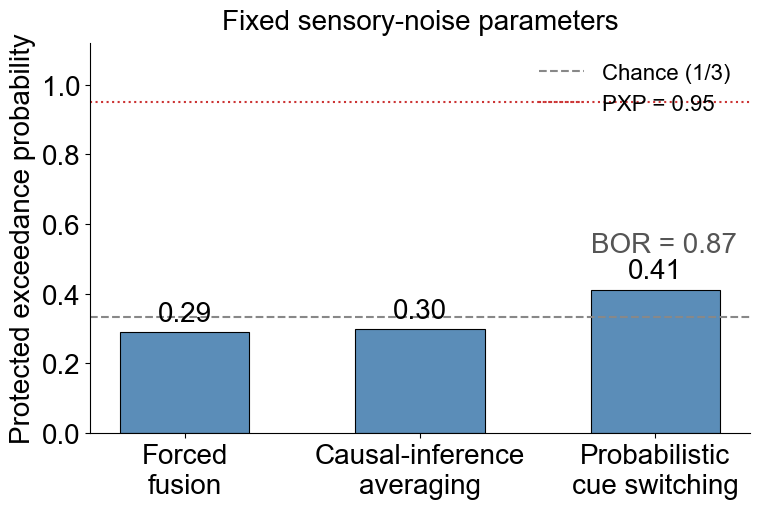

In [18]:
def plot_pxp(bms_result, title_suffix='', save_path=None):
    plt.rcParams.update({
        'font.size': 20, 'font.weight': 'normal',
        'axes.labelweight': 'normal', 'axes.titleweight': 'normal',
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    })
    K = len(bms_result['models'])
    pxp = bms_result['pxp']
    short = [m.replace(' ', '\n', 1) for m in bms_result['models']]

    fig, ax = plt.subplots(figsize=(8, 5.5))
    bars = ax.bar(np.arange(K), pxp, width=0.55, color='#5b8db8',
                  edgecolor='black', linewidth=0.8)
    ax.axhline(1 / K, color='#888888', linestyle='--', linewidth=1.5, label=f'Chance (1/{K})')
    ax.axhline(0.95, color='#cc3333', linestyle=':', linewidth=1.5, label='PXP = 0.95')
    for bar, val in zip(bars, pxp):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=20)
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels(short, fontsize=20)
    ax.set_ylabel('Protected exceedance probability', fontsize=20)
    ax.set_ylim(0, 1.12)
    ax.tick_params(axis='y', labelsize=20)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.text(0.98, 0.45, f"BOR = {bms_result['bor']:.2f}", transform=ax.transAxes,
            ha='right', va='bottom', fontsize=20, color='#555555')
    if title_suffix:
        ax.set_title(title_suffix, fontsize=20, pad=10)
    ax.legend(fontsize=16, frameon=False, loc='upper right')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=900, bbox_inches='tight')
        plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()


plot_pxp(bms_free, title_suffix='Free sensory-noise parameters',
         save_path='pxp_threeModels_freeSigma.pdf')
plot_pxp(bms_uni, title_suffix='Fixed sensory-noise parameters',
         save_path='pxp_threeModels_unimodalSigma.pdf')

## 7. Compact per-participant table (free-sigma source)

In [19]:
def add_base_model_deltas(df_results, base_model=BASE_MODEL):
    df = df_results.copy()
    base = df.loc[df['modelType'] == base_model, ['participantID', 'AIC', 'BIC']].rename(
        columns={'AIC': 'base_AIC', 'BIC': 'base_BIC'}
    )
    missing_base = sorted(set(df['participantID']) - set(base['participantID']))
    if missing_base:
        raise ValueError(f"Missing {base_model!r} rows for participants: {missing_base}")

    df = df.merge(base, on='participantID', how='left', validate='many_to_one')
    df['deltaAIC'] = df['AIC'] - df['base_AIC']
    df['deltaBIC'] = df['BIC'] - df['base_BIC']
    return df


def comparison_table(df_results, base_model=BASE_MODEL):
    df = add_base_model_deltas(df_results, base_model=base_model)
    pivot = df.pivot_table(index='participantID', columns='modelType',
                            values=['logLikelihood', 'AIC', 'deltaAIC', 'BIC', 'deltaBIC'])
    # Reorder model columns
    pivot = pivot.reindex(columns=pd.MultiIndex.from_product(
        [['logLikelihood', 'AIC', 'deltaAIC', 'BIC', 'deltaBIC'], MODEL_ORDER]
    ))
    return pivot


def sum_delta_aic(df_results, base_model=BASE_MODEL):
    df = add_base_model_deltas(df_results, base_model=base_model)
    summary = df.groupby('modelType')['deltaAIC'].sum().reindex(MODEL_ORDER)
    return summary.rename('sum_deltaAIC').to_frame()


free_table = comparison_table(df_free)
uni_table = comparison_table(df_unimodal)
free_sum_delta_aic = sum_delta_aic(df_free)
uni_sum_delta_aic = sum_delta_aic(df_unimodal)

print('Free sigma — per-participant comparison')
print(free_table.round(2))
print(f'\nFree sigma — sum ΔAIC relative to {BASE_MODEL}')
print(free_sum_delta_aic.round(2))
print('\nUnimodal sigma — per-participant comparison')
print(uni_table.round(2))
print(f'\nUnimodal sigma — sum ΔAIC relative to {BASE_MODEL}')
print(uni_sum_delta_aic.round(2))

Free sigma — per-participant comparison
              logLikelihood                             \
              Forced fusion Causal-inference averaging   
participantID                                            
as                 -1119.22                   -1119.37   
dt                 -1270.06                   -1269.77   
hh                  -594.02                    -591.95   
ip                 -1198.96                   -1197.16   
ln2                -1080.51                   -1078.69   
mh                 -1218.31                   -1214.46   
ml                 -1252.69                   -1252.40   
mt                 -1104.00                   -1100.12   
oy                 -1158.78                   -1156.25   
qs                 -1245.27                   -1246.13   
sx                 -1075.80                   -1075.46   

                                                    AIC  \
              Probabilistic cue switching Forced fusion   
participantID                